# Cell Mosaic Demo

This notebook walks through the full `cell_mosaics` workflow, comparing
3 outline **shape kinds** (`irregular`, `convex`, `concave`) crossed with
2 spatial **grid kinds** (`random` = complete spatial randomness,
`regular` = a jittered, mostly-regular grid) -- 6 synthetic mosaics total.

1. Generate the 6 mosaics and plot them on a 3x2 grid
2. Compute a coverage density map (single example mosaic)
3. Analyse mosaic regularity for all 6 with:
   - Nearest-neighbour distance (NND) & regularity index
   - Density Recovery Profile (DRP) & effective radius
   - Voronoi domain analysis
4. Compare each metric across the 6 mosaics, reusing the 3x2 (or 6x2)
   grid layout so the same position always means the same mosaic.

In [1]:
import matplotlib.pyplot as plt

import cell_mosaics as cm

## 1 · Generate the 6 mosaics

Colors come from `tab20`: each shape kind gets one dark/light pair, with
`random` as the brighter color and `regular` as the darker one.

In [2]:
FIELD_SIZE = 1000
N_CELLS    = 80
SEED       = 42
BOUNDS     = cm.toy_data.bounds_from_field_size(FIELD_SIZE)   # (0, 1000, 0, 1000)

SHAPE_KINDS = ["irregular", "convex", "concave"]
GRID_KINDS  = ["random", "regular"]

_tab20 = plt.get_cmap("tab20")
COLORS = {
    (shape, grid): _tab20(2 * i + (1 if grid == "random" else 0))
    for i, shape in enumerate(SHAPE_KINDS)
    for grid in GRID_KINDS
}

cases = {}
for shape in SHAPE_KINDS:
    for grid in GRID_KINDS:
        outlines = cm.generate_example_neurons(
            n_cells=N_CELLS,
            field_size=FIELD_SIZE,
            cell_size_range=(30, 80),
            polygon_type=shape,
            arrangement=grid,
            seed=SEED,
        )
        cases[(shape, grid)] = {
            "outlines": outlines,
            "centroids": cm.compute_centroids(outlines),
        }

print(f"{len(cases)} cases generated: {list(cases)}")

6 cases generated: [('irregular', 'random'), ('irregular', 'regular'), ('convex', 'random'), ('convex', 'regular'), ('concave', 'random'), ('concave', 'regular')]


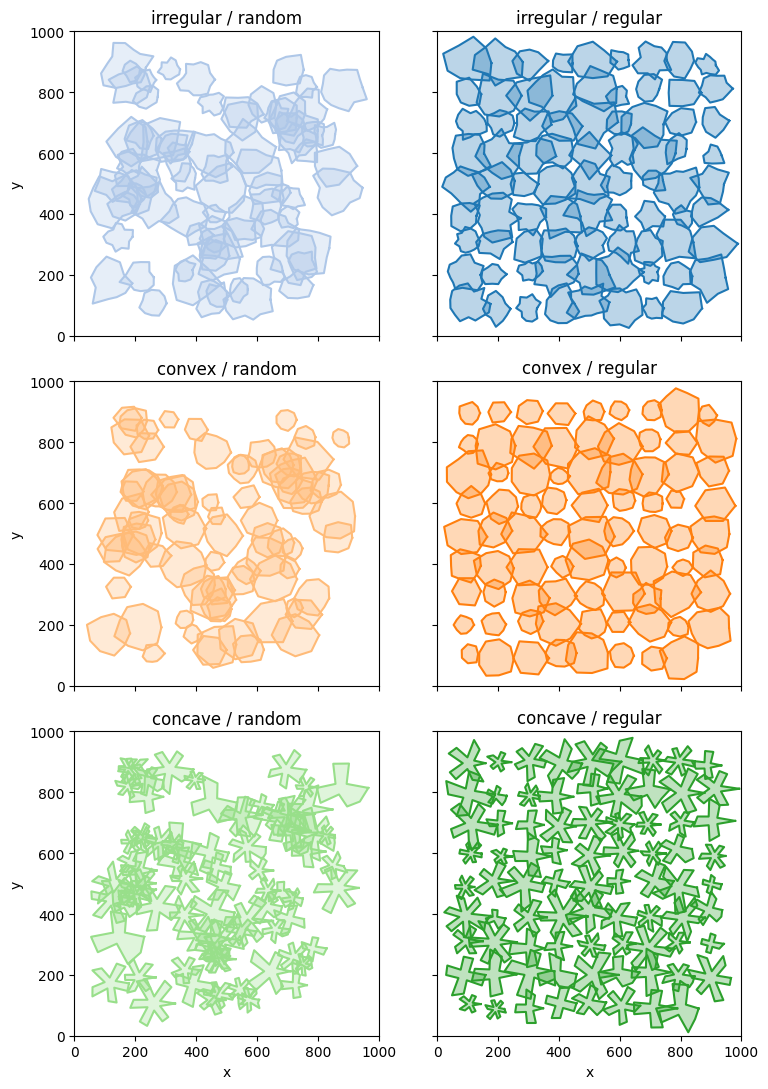

In [3]:
fig, axes = plt.subplots(len(SHAPE_KINDS), len(GRID_KINDS), figsize=(8, 11),
                          sharex=True, sharey=True)
for i, shape in enumerate(SHAPE_KINDS):
    for j, grid in enumerate(GRID_KINDS):
        ax = axes[i, j]
        color = COLORS[(shape, grid)]
        for outline in cases[(shape, grid)]["outlines"]:
            cm.plot_polygon(ax, outline, facecolor=color, edgecolor=color, facealpha=0.3)
        ax.set_xlim(0, FIELD_SIZE)
        ax.set_ylim(0, FIELD_SIZE)
        ax.set_aspect("equal")
        ax.set_title(f"{shape} / {grid}")
        if i == len(SHAPE_KINDS) - 1:
            ax.set_xlabel("x")
        if j == 0:
            ax.set_ylabel("y")
plt.tight_layout()
plt.show()

## 2 · Coverage density map

The mapper rasterises each polygon onto a grid and counts how many outlines
overlap each pixel. Shown for a single example mosaic (`irregular` / `random`).

In [4]:
example_shape, example_grid = SHAPE_KINDS[0], GRID_KINDS[0]
example_outlines = cases[(example_shape, example_grid)]["outlines"]

mapper = cm.CoverageDensityMapper(field_bounds=BOUNDS, resolution=500)
mapper.add_multiple_polygons(example_outlines)

stats = mapper.get_coverage_statistics()
print(f"Coverage statistics ({example_shape} / {example_grid}):")
for k, v in stats.items():
    print(f"  {k}: {v:.3f}" if isinstance(v, float) else f"  {k}: {v}")

Coverage statistics (irregular / random):
  max_coverage: 6
  mean_coverage: 1.560
  coverage_std: 0.851
  area_covered_fraction: 0.462
  total_pixels: 250000
  covered_pixels: 115609


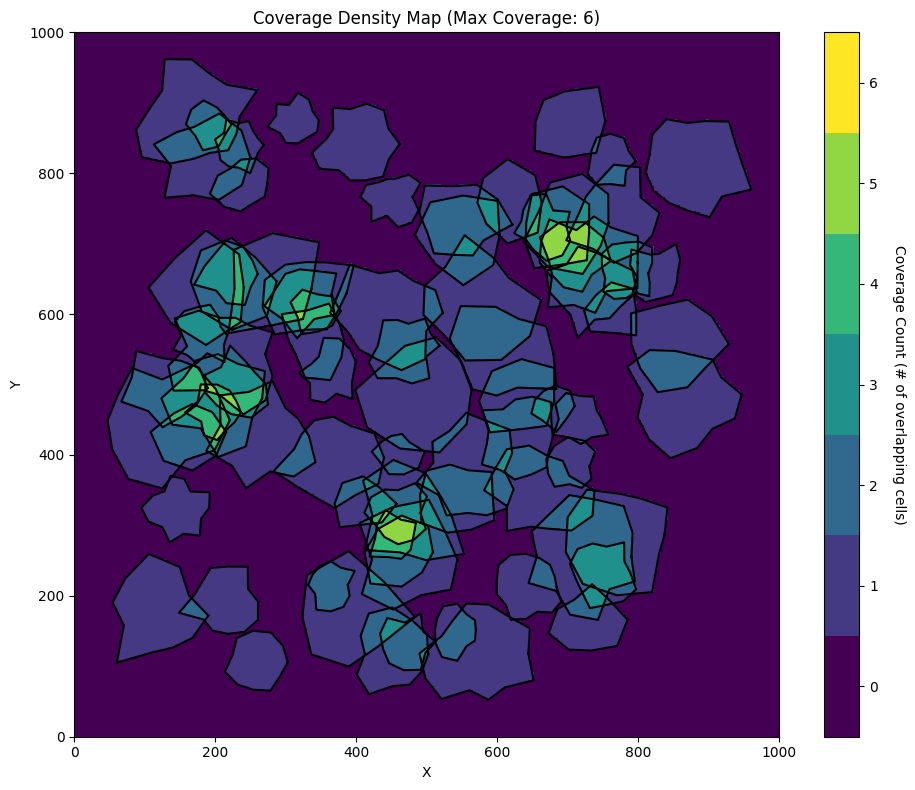

In [5]:
fig, ax, _ = mapper.plot_coverage(plot_cell_outlines=True)
plt.tight_layout()
plt.show()

## 3 · Mosaic metrics

All metrics operate on **cell centroids** rather than full outlines.
Compute NND, DRP (+ effective radius), and Voronoi domain stats for all 6
mosaics up front, then compare them below.

In [6]:
# Voronoi cell area blows up whenever a cell's true neighbor lies outside the
# field -- not just for cells on the convex hull. With only N_CELLS=80, the
# default one-cell-length margin lets a few boundary-adjacent cells through
# with wildly inflated areas (especially for `random`, where a cell can sit
# just inside the margin next to a locally sparse patch). VORONOI_MARGIN_FACTOR
# trades sample size for a margin wide enough to exclude those.
VORONOI_MARGIN_FACTOR = 2.5

for (shape, grid), case in cases.items():
    centroids = case["centroids"]
    case["nnd"] = cm.nnd_statistics(centroids)
    case["vor"] = cm.voronoi_analysis(centroids, field_bounds=BOUNDS, margin_factor=VORONOI_MARGIN_FACTOR)
    case["drp"] = cm.density_recovery_profile(centroids, BOUNDS, n_bins=30, max_radius=300)
    case["drp_re"] = cm.drp_effective_radius(centroids, BOUNDS, n_bins=30, max_radius=300)

print(f"{'Shape':<10} {'Grid':<8} {'NND RI':>8} {'Vor CV':>8} {'Vor n':>6} {'DRP r_e':>8}")
print("-" * 54)
for (shape, grid), case in cases.items():
    print(f"{shape:<10} {grid:<8} "
          f"{case['nnd']['regularity_index']:>8.2f} "
          f"{case['vor']['cv_area']:>8.3f} "
          f"{case['vor']['n_interior']:>6d} "
          f"{case['drp_re']['effective_radius']:>8.1f}")

Shape      Grid       NND RI   Vor CV  Vor n  DRP r_e
------------------------------------------------------
irregular  random       1.87    0.447     28      0.7
irregular  regular     10.99    0.112     25    116.4
convex     random       1.83    0.430     28      0.7
convex     regular     10.36    0.122     25    116.4
concave    random       1.85    0.429     28     10.0
concave    regular     10.48    0.114     25    116.8


### 3a · Nearest-neighbour distance (NND)

The **regularity index** (RI = mean NND / std NND) quantifies how evenly
spaced cells are. A Poisson (random) process yields RI ≈ 1.9; ordered
mosaics typically exceed 4.

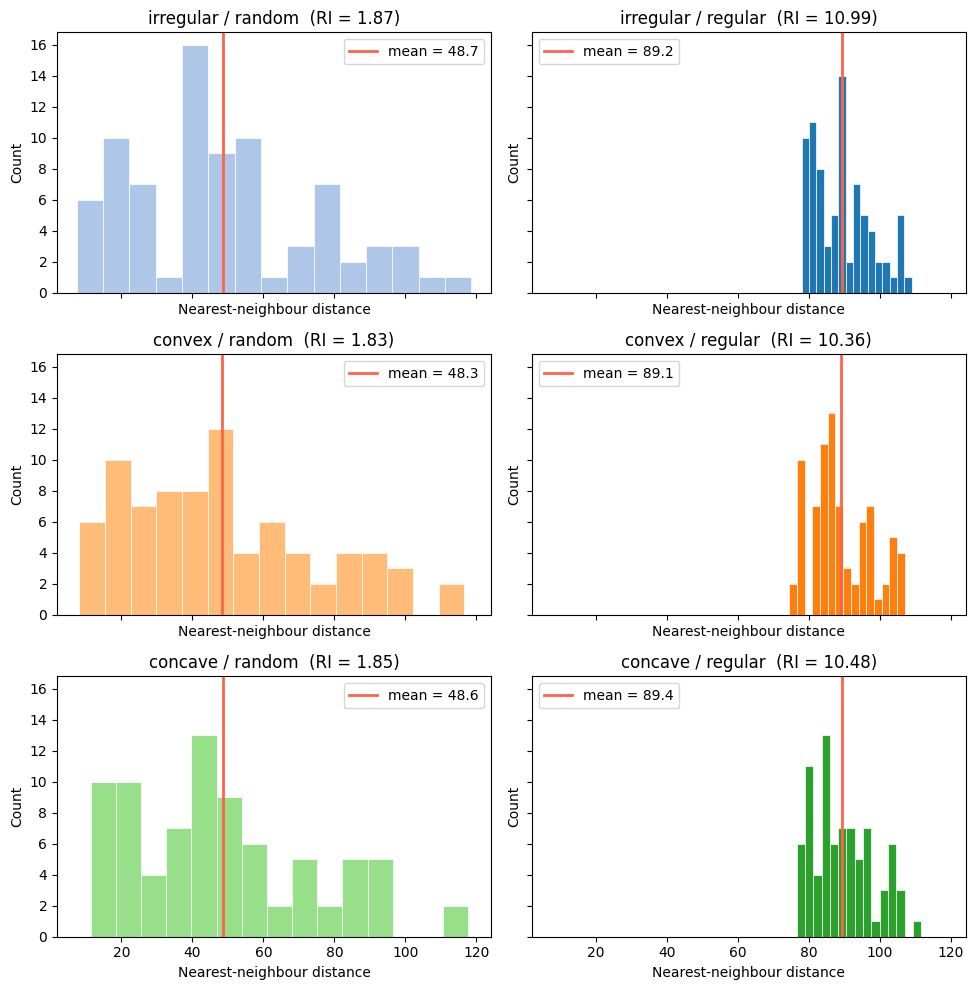

In [7]:
fig, axes = plt.subplots(len(SHAPE_KINDS), len(GRID_KINDS), figsize=(10, 10),
                          sharex=True, sharey=True)
for i, shape in enumerate(SHAPE_KINDS):
    for j, grid in enumerate(GRID_KINDS):
        ax = axes[i, j]
        case = cases[(shape, grid)]
        cm.plot_nnd(case["nnd"], ax=ax, color=COLORS[(shape, grid)])
        ax.set_title(f"{shape} / {grid}  (RI = {case['nnd']['regularity_index']:.2f})")
plt.tight_layout()
plt.show()

### 3b · Density Recovery Profile (DRP)

The DRP (Rodieck 1991) shows the local density of neighbours as a function
of distance from each cell, normalised to the global density. The
**effective radius** quantifies the exclusion zone as the radius of an
equivalent, completely empty disc.

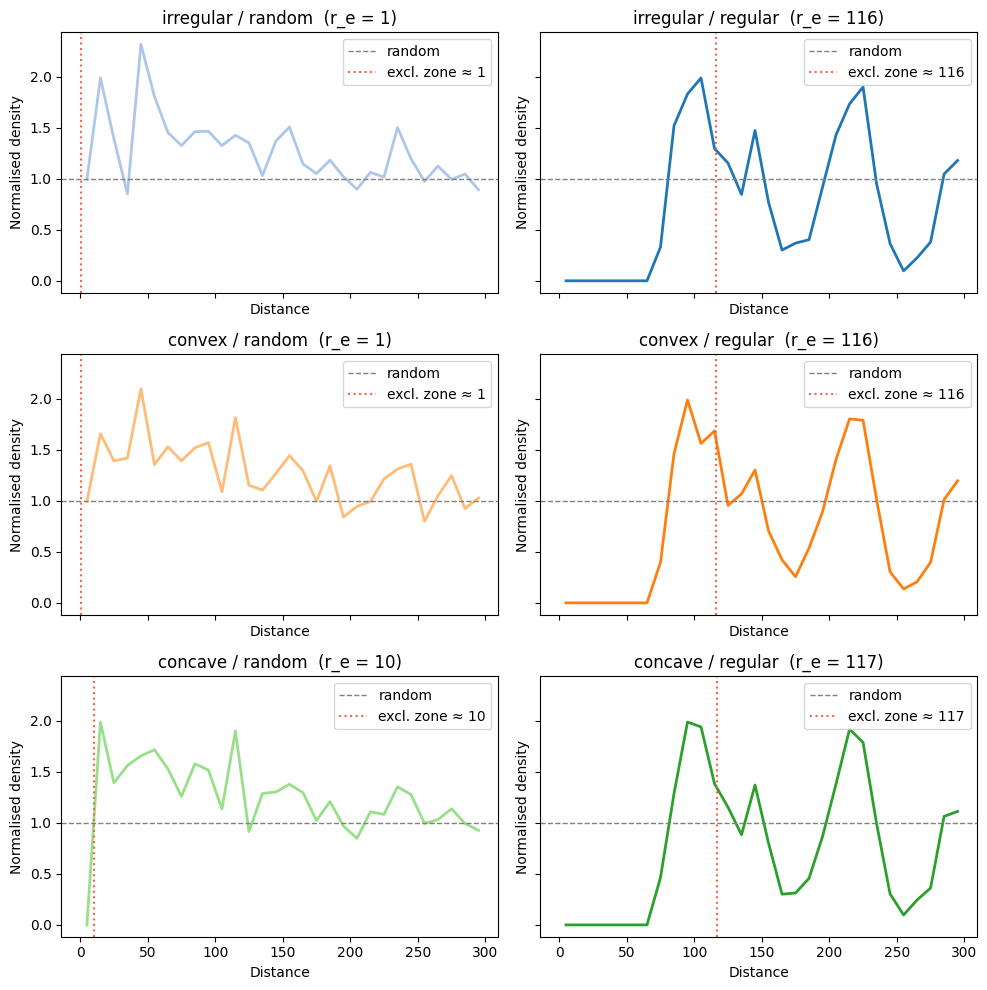

In [8]:
fig, axes = plt.subplots(len(SHAPE_KINDS), len(GRID_KINDS), figsize=(10, 10),
                          sharex=True, sharey=True)
for i, shape in enumerate(SHAPE_KINDS):
    for j, grid in enumerate(GRID_KINDS):
        ax = axes[i, j]
        case = cases[(shape, grid)]
        bin_centers, drp = case["drp"]
        cm.plot_drp(bin_centers, drp, ax=ax, color=COLORS[(shape, grid)],
                    effective_radius=case["drp_re"]["effective_radius"])
        ax.set_title(f"{shape} / {grid}  (r_e = {case['drp_re']['effective_radius']:.0f})")
plt.tight_layout()
plt.show()

### 3c · Voronoi domain analysis

Each cell's Voronoi domain captures its "territory". The coefficient of
variation (CV) of domain areas is another regularity measure — lower CV
means more regular tiling. Boundary cells are excluded with a wider-than-
default margin (`VORONOI_MARGIN_FACTOR`, above) to avoid a few edge-adjacent
cells with wildly inflated areas dominating the CV -- see `n_interior` in
the table above for how many cells that leaves per mosaic. Two plots per
mosaic (tessellation + area histogram), so this uses a 6x2 grid: one row
per (shape, grid) case.

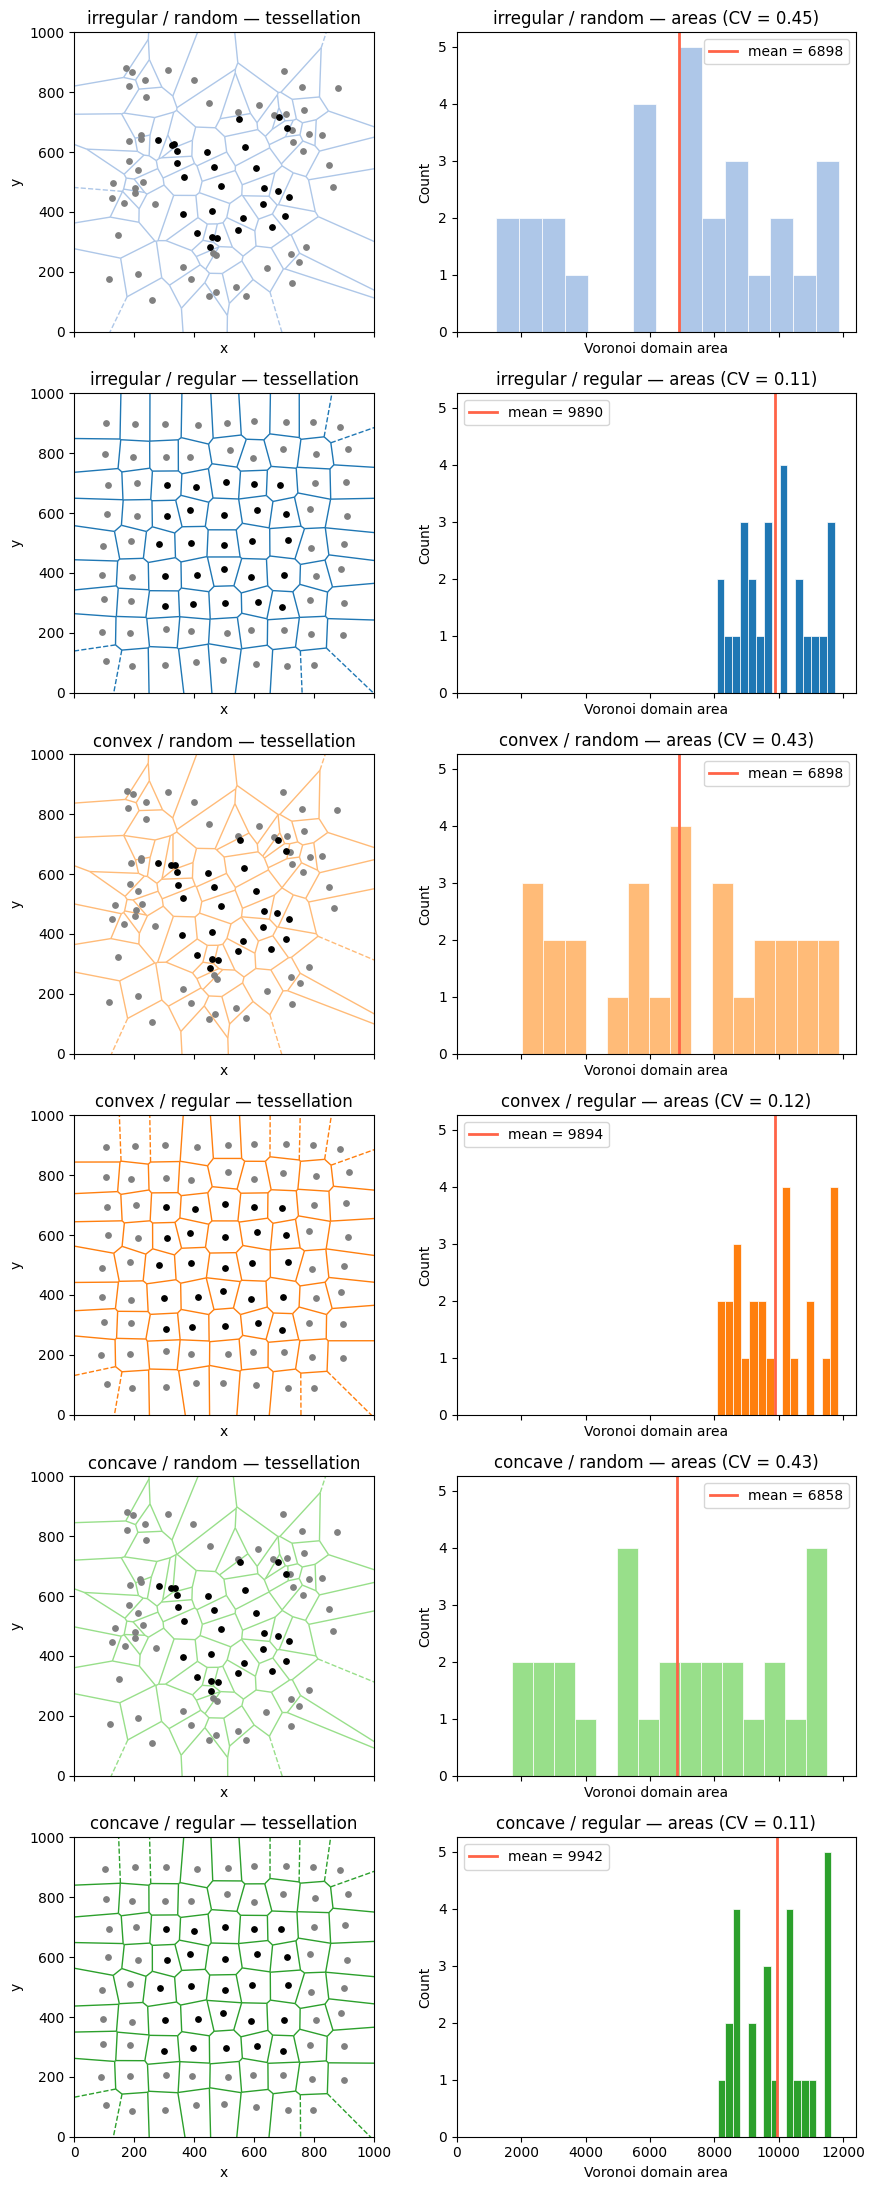

In [9]:
fig, axes = plt.subplots(len(cases), 2, figsize=(9, 22), sharex='col', sharey='col')
for k, ((shape, grid), case) in enumerate(cases.items()):
    color = COLORS[(shape, grid)]
    cm.plot_voronoi_tessellation(case["centroids"], ax=axes[k, 0], field_bounds=BOUNDS,
                                  interior_mask=case["vor"]["interior_mask"],
                                  point_color="black", line_color=color)
    axes[k, 0].set_title(f"{shape} / {grid} — tessellation")

    cm.plot_voronoi_areas(case["vor"], ax=axes[k, 1], color=color)
    axes[k, 1].set_title(f"{shape} / {grid} — areas (CV = {case['vor']['cv_area']:.2f})")
    axes[k, 1].set_xlim(0, None)
plt.tight_layout()
plt.show()